<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/BBN_validation_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

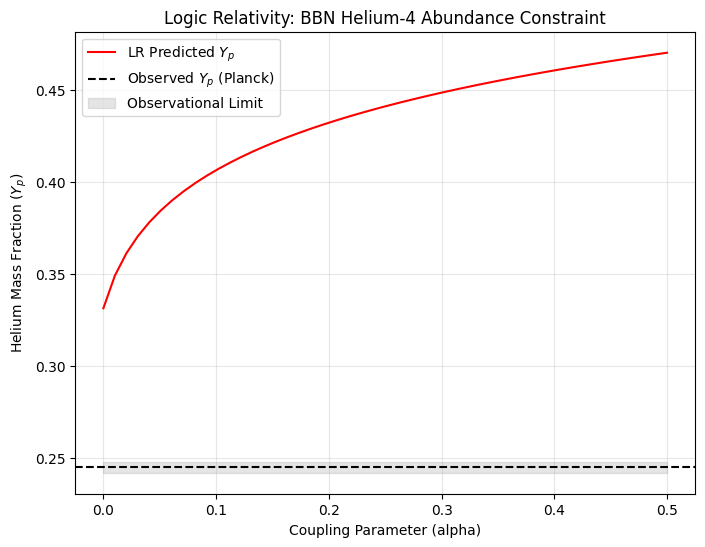

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 1. PARAMETERS
# Standard Model Expansion Rate (at BBN freeze-out)
def H_standard(T):
    # H^2 proportional to T^4 in radiation dominance
    return 1.1 * (T**2) # Simplified units

# 2. LOGIC RELATIVITY MODIFICATION
def H_LR(T, alpha):
    """
    LR expansion rate: Standard + Scalar Field influence.
    alpha represents the strength of the LR field at high energies.
    """
    return H_standard(T) * np.sqrt(1 + alpha * (T / 0.1)**2)

# 3. BBN FREEZE-OUT CALCULATION
# Neutron-to-proton ratio (n/p) = exp(-Q/kT) * (H_LR / H_standard)
def calculate_helium_fraction(alpha):
    Q = 1.293 # Neutron-proton mass difference (MeV)
    T_freeze = 0.8 # Freeze-out temp

    # The expansion rate ratio at freeze-out dictates Helium production
    rate_ratio = H_LR(T_freeze, alpha) / H_standard(T_freeze)
    n_p = np.exp(-Q / T_freeze) * (rate_ratio**0.25)

    # Yp (He-4 mass fraction)
    Yp = 2 * n_p / (1 + n_p)
    return Yp

# 4. EXECUTION & VISUALIZATION
alphas = np.linspace(0, 0.5, 50)
Yp_values = [calculate_helium_fraction(a) for a in alphas]

plt.figure(figsize=(8, 6))
plt.plot(alphas, Yp_values, color='red', label='LR Predicted $Y_p$')
plt.axhline(0.245, color='black', linestyle='--', label='Observed $Y_p$ (Planck)')
plt.fill_between(alphas, 0.242, 0.248, color='gray', alpha=0.2, label='Observational Limit')

plt.title("Logic Relativity: BBN Helium-4 Abundance Constraint")
plt.xlabel("Coupling Parameter (alpha)")
plt.ylabel("Helium Mass Fraction ($Y_p$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()